<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [25]:
aug_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/augmented_images/augmented_images1",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

Found 13640 files belonging to 62 classes.


In [3]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [4]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [26]:
aug_ds = aug_ds.map(process)

images, label = next(iter(aug_ds))
images.shape, label.shape

(TensorShape([64, 128, 128, 3]), TensorShape([64]))

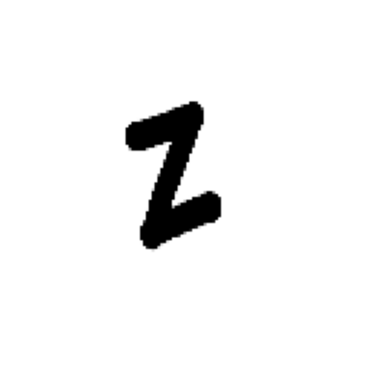

In [27]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [5]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [6]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

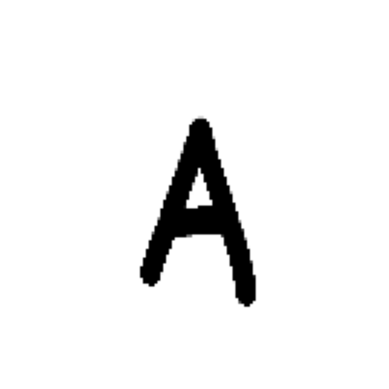

In [7]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [10]:
#model 1
model1 = Sequential([
    Conv2D(32, (3,3), activation= 'relu', padding = "same", input_shape = (128, 128, 3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(160, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,574 (6.09 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history1 = model1.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step - accuracy: 0.0649 - loss: 3.9381 - val_accuracy: 0.2654 - val_loss: 3.0139
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 261ms/step - accuracy: 0.4597 - loss: 2.0412 - val_accuracy: 0.6378 - val_loss: 1.3792
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step - accuracy: 0.7111 - loss: 1.0039 - val_accuracy: 0.6745 - val_loss: 1.2564
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 252ms/step - accuracy: 0.8134 - loss: 0.6085 - val_accuracy: 0.6891 - val_loss: 1.2395
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - accuracy: 0.8827 - loss: 0.3960 - val_accuracy: 0.6965 - val_loss: 1.3500
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 280ms/step - accuracy: 0.9300 - loss: 0.2224 - val_accuracy: 0.6965 - val_loss: 1.4979
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step - accuracy: 0.9523 - loss: 0.1612 - val_accuracy: 0.7126 - val_loss: 1.4416
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 251ms/step - accuracy: 0.9692 - loss: 0.0976 - val_accura

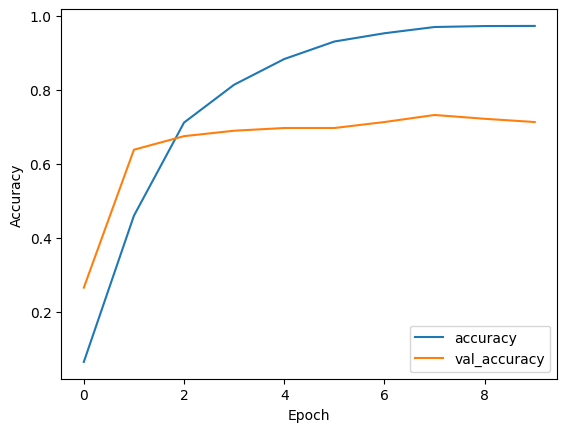

In [12]:
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [29]:
#model 2
model2 = Sequential([
    Conv2D(32, (3,3), activation= 'relu',  input_shape = (128, 128, 3)),

    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(64, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(128, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dense(62, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,974 (6.50 MB)

 Trainable params: 1,702,974 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history2 = model2.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 272ms/step - accuracy: 0.0345 - loss: 4.0746 - val_accuracy: 0.0836 - val_loss: 3.7359
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 264ms/step - accuracy: 0.2306 - loss: 3.0712 - val_accuracy: 0.3871 - val_loss: 2.2795
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 278ms/step - accuracy: 0.5154 - loss: 1.7697 - val_accuracy: 0.5425 - val_loss: 1.7905
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.6932 - loss: 1.0641 - val_accuracy: 0.5484 - val_loss: 1.8220
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 258ms/step - accuracy: 0.8174 - loss: 0.6229 - val_accuracy: 0.5938 - val_loss: 1.9139
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.8776 - loss: 0.3860 - val_accuracy: 0.5894 - val_loss: 2.2508
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - accuracy: 0.9282 - loss: 0.2239 - val_accuracy: 0.6085 - val_loss: 2.4132
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 269ms/step - accuracy: 0.9571 - loss: 0.1528 - val_accu

In [28]:
history21= model2.fit(aug_ds, epochs=10)

Epoch 1/10
 47/214 ━━━━━━━━━━━━━━━━━━━━ 47:26 17s/step - accuracy: 0.4486 - loss: 2.1882

KeyboardInterrupt: 

here we see our model is overfiiting so we need to used batchnormlization as well as dropout for better and also that model we will train aith augmenta data also